In [3]:
from pandas import read_csv
from pandas.plotting import scatter_matrix
from matplotlib import pyplot
from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.feature_selection import RFE


In [4]:
 dataset = read_csv("Bank_Personal_Loan_Modelling.csv")

In [5]:
# shape
print(dataset.shape)

(5000, 14)


In [6]:
#head
dataset.head()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1.6,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1.5,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1.0,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2.7,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1.0,2,0,0,0,0,0,1


In [7]:
#describe
print(dataset.describe())

                ID          Age   Experience       Income      ZIP Code  \
count  5000.000000  5000.000000  5000.000000  5000.000000   5000.000000   
mean   2500.500000    45.338400    20.104600    73.774200  93152.503000   
std    1443.520003    11.463166    11.467954    46.033729   2121.852197   
min       1.000000    23.000000    -3.000000     8.000000   9307.000000   
25%    1250.750000    35.000000    10.000000    39.000000  91911.000000   
50%    2500.500000    45.000000    20.000000    64.000000  93437.000000   
75%    3750.250000    55.000000    30.000000    98.000000  94608.000000   
max    5000.000000    67.000000    43.000000   224.000000  96651.000000   

            Family        CCAvg    Education     Mortgage  Personal Loan  \
count  5000.000000  5000.000000  5000.000000  5000.000000    5000.000000   
mean      2.396400     1.937938     1.881000    56.498800       0.096000   
std       1.147663     1.747659     0.839869   101.713802       0.294621   
min       1.000000  

In [8]:
#check for nulls
dataset.isnull().values.any()

False

In [9]:
dataset['Personal Loan'].value_counts()

0    4520
1     480
Name: Personal Loan, dtype: int64

### Observation Data is imbalanced

In [10]:
dataset.groupby('Personal Loan').mean()

,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Securities Account,CD Account,Online,CreditCard
Personal Loan,,,,,,,,,,,,,
0,2512.165487,45.367257,20.132301,66.237389,93152.428761,2.373451,1.729009,1.843584,51.789381,0.102212,0.035841,0.595796,0.293584
1,2390.650000,45.066667,19.843750,144.745833,93153.202083,2.612500,3.905354,2.233333,100.845833,0.125000,0.291667,0.606250,0.297917


### Observations

#### 1.Average income of people who got personal loan is higher than people who did not.
#### 2.Credit card spending average is also higher for people who bought loans
#### 3.Education level of people who bought personal loan is also higher


In [11]:
columns = list(dataset)[0:-1] # Excluding Id column which has only 


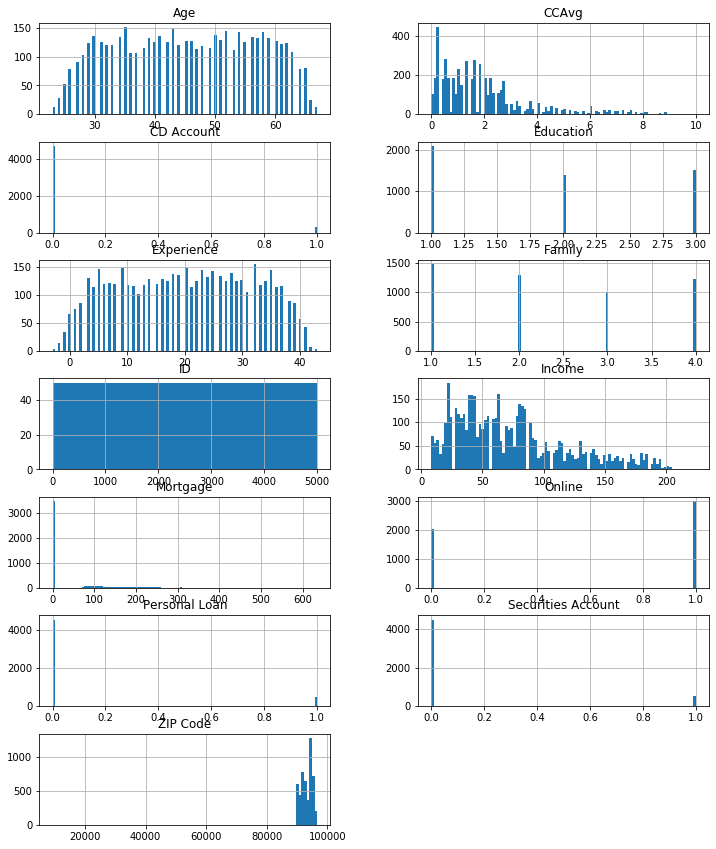

In [12]:
dataset[columns].hist(stacked=False, bins=100, figsize=(12,30), layout=(14,2)); 

In [13]:
# Removed ID and Personal Loan
X = dataset.drop(columns=['ID', 'Personal Loan'])

In [14]:
X.describe()
X.count()

Age                   5000
Experience            5000
Income                5000
ZIP Code              5000
Family                5000
CCAvg                 5000
Education             5000
Mortgage              5000
Securities Account    5000
CD Account            5000
Online                5000
CreditCard            5000
dtype: int64

In [15]:
y=dataset['Personal Loan']

In [16]:
y.tail()


4995    0
4996    0
4997    0
4998    0
4999    0
Name: Personal Loan, dtype: int64

In [17]:
# Select Features by using RFE method
model = LogisticRegression()
rfe = RFE(model, 5)
fit = rfe.fit(X, y)
print("Num Features: %s" % (fit.n_features_))
print("Selected Features: %s" % (fit.support_))
print("Feature Ranking: %s" % (fit.ranking_))

Num Features: 5
Selected Features: [False False False False False  True  True False  True  True False  True]
Feature Ranking: [5 4 6 8 3 1 1 7 1 1 2 1]


/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)
/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22.

It looks like the following are important features [CCAvg,Education,Securities Account,CD Account,CreditCard] ARE IMPORTANT FEATURES

In [18]:
X_train, X_test, y_train, y_test = train_test_split( X, Y, test_size = 0.3, random_state = 42 )
logit = sm.Logit( y_train, sm.add_constant( X_train ) )
lg = logit.fit()
lg.summary2()

NameError: name 'Y' is not defined

### Important features p>0.05 are Age,Experience,Zip Code,Mortgage, CCAvg

In [ ]:
dataset.corr() # It will show correlation matrix 

### Logistic Regression

In [23]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)
logreg = LogisticRegression()
logreg.fit(X_train, y_train)

/usr/local/anaconda3/lib/python3.7/site-packages/sklearn/linear_model/logistic.py:432: FutureWarning: Default solver will be changed to 'lbfgs' in 0.22. Specify a solver to silence this warning.
  FutureWarning)


LogisticRegression(C=1.0, class_weight=None, dual=False, fit_intercept=True,
                   intercept_scaling=1, l1_ratio=None, max_iter=100,
                   multi_class='warn', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [24]:
y_pred_train = logreg.predict(X_train)
print('Accuracy of logistic regression classifier on train set: {:.2f}'.format(logreg.score(X_train, y_train)))




Accuracy of logistic regression classifier on train set: 0.90


In [25]:
y_pred = logreg.predict(X_test)
print('Accuracy of logistic regression classifier on test set: {:.2f}'.format(logreg.score(X_test, y_test)))

Accuracy of logistic regression classifier on test set: 0.92


In [26]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[1329   43]
 [  78   50]]


In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.94      0.92      1351
           1       0.09      0.05      0.07       149

    accuracy                           0.85      1500
   macro avg       0.49      0.50      0.49      1500
weighted avg       0.82      0.85      0.83      1500



In [40]:
from sklearn.metrics import f1_score

print("F1 Score: {}".format(f1_score(y_test,y_pred)))

F1 Score: 0.06611570247933884


## The result is telling us that we have 1329+50 correct predictions and 78+43 incorrect predictions.LOGISTIC REGRESSION

## Naive Bayes

In [28]:
# creatw the model
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)
naiveBayesModel = GaussianNB()

naiveBayesModel.fit(X_train, y_train.ravel())

GaussianNB(priors=None, var_smoothing=1e-09)

In [29]:
personal_loan_predicts = naiveBayesModel.predict(X_train)

from sklearn import metrics

print("Model Accuracy Train: {0:.4f}".format(metrics.accuracy_score(y_train, personal_loan_predicts)))
print()

Model Accuracy Train: 0.8943



In [30]:
personal_loan_predicts = naiveBayesModel.predict(X_test)

from sklearn import metrics

print("Model Accuracy Test: {0:.4f}".format(metrics.accuracy_score(y_test, personal_loan_predicts)))
print()

Model Accuracy Test: 0.8840



In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, personal_loan_predicts)
print(confusion_matrix)

[[1241  110]
 [  64   85]]


In [32]:
print(classification_report(y_test, personal_loan_predicts))

              precision    recall  f1-score   support

           0       0.95      0.92      0.93      1351
           1       0.44      0.57      0.49       149

    accuracy                           0.88      1500
   macro avg       0.69      0.74      0.71      1500
weighted avg       0.90      0.88      0.89      1500



In [37]:
from sklearn.metrics import f1_score

print("F1 Score: {}".format(f1_score(y_test,personal_loan_predicts)))

F1 Score: 0.4941860465116279


##  The result is telling us that we have 1241+85 correct predictions and 110+64 incorrect predictions. Naive Bayes

## KNN


In [34]:
# Split X and y into training and test set in 75:25 ratio

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)
NNH = KNeighborsClassifier(n_neighbors= 10 , weights = 'distance' )

NNH.fit(X_train, y_train)
# For every test data point, predict it's label based on 10 nearest neighbours in this model. The majority class will 
# be assigned to the test data point

predicted_labels = NNH.predict(X_test)
NNH.score(X_test, y_test)

0.9

In [35]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, predicted_labels)
print(confusion_matrix)

[[1326   25]
 [ 125   24]]


In [36]:
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.91      0.98      0.95      1351
           1       0.49      0.16      0.24       149

    accuracy                           0.90      1500
   macro avg       0.70      0.57      0.59      1500
weighted avg       0.87      0.90      0.88      1500



##  The result is telling us that we have 1326+24 correct predictions and 125+25 incorrect predictions. KNN

## Choice of Model

#Let us see the F1-scores that tells the balance between the precsion and Recall 

#Accuracy of logistic regression classifier on train set: 0.92
#Accuracy of Naive Bayes on train set: 0.8840
#Accuracy of KNNon train set :0.9

#Clearly from Accuracy figures we see LR to be good proposition
    

#Now let us see precsion and recall focussed data
    
#We are interested in converting liabilities customer , here F1 is important factor .

#F1 scores for corrrct predictions is as below 
#LR - F1 for predicting people taking loan is 0.07
#NB - F1 for predicting people taking loan is 0.49
#KNN - F1 for predicting people taking loan is 0.24

## It is clear that F1 for correct prediction in  NB is better .






